# 实验六 - 改进版：Adam优化器 + 学习率衰减## 📋 改进点1. **Adam优化器**: 自适应学习率，收敛更稳定2. **余弦退火**: 学习率从0.01平滑降至接近03. **增加迭代次数**: 从300增至500 epochs4. **详细Loss监控**: 记录并可视化各项loss变化## ⚙️ 参数配置- **优化器**: Adam (lr=0.01)- **学习率调度**: CosineAnnealingLR- **迭代次数**: 500 epochs- **正则化权重**: laplacian=0.8, edge=0.1, normal=0.01- **输出目录**: `output_meshes_improved/`## 📊 预期改进- ✅ 收敛曲线平滑，无震荡- ✅ 最终Loss更低- ✅ 形状更加精细---

## 1. 环境检查

In [5]:
import torch
import pytorch3d
print(f"PyTorch版本: {torch.__version__}")
print(f"PyTorch3D版本: {pytorch3d.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")

PyTorch版本: 2.9.1+cu128
PyTorch3D版本: 0.7.8
CUDA可用: True


## 2. 完整代码（改进版 - Adam优化器）

📊 Epoch 499/500
   Total Loss:      0.004449
   Silhouette Loss: 0.001038
   Laplacian Loss:  0.003592
   Edge Loss:       0.002787
   Normal Loss:     0.025821
   Learning Rate:   0.000000
------------------------------------------------------------
💾 已保存: output_meshes_improved/mesh_epoch_499.obj



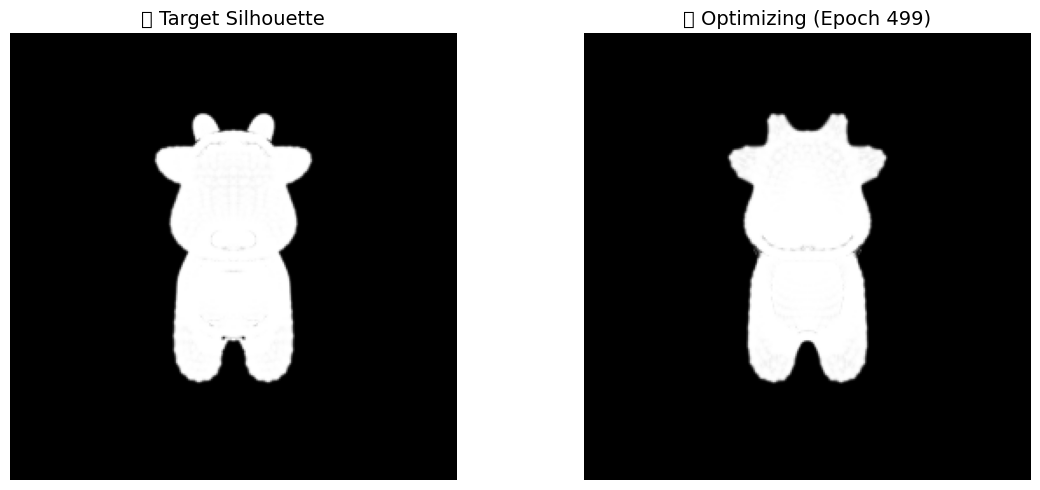


🎉 优化训练完成！
📁 所有模型已保存至: output_meshes_improved/
📊 最终 Total Loss: 0.004449
📊 最终 Silhouette Loss: 0.001038


/tmp/ipykernel_7591/2581787197.py:223: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7591/2581787197.py:223: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


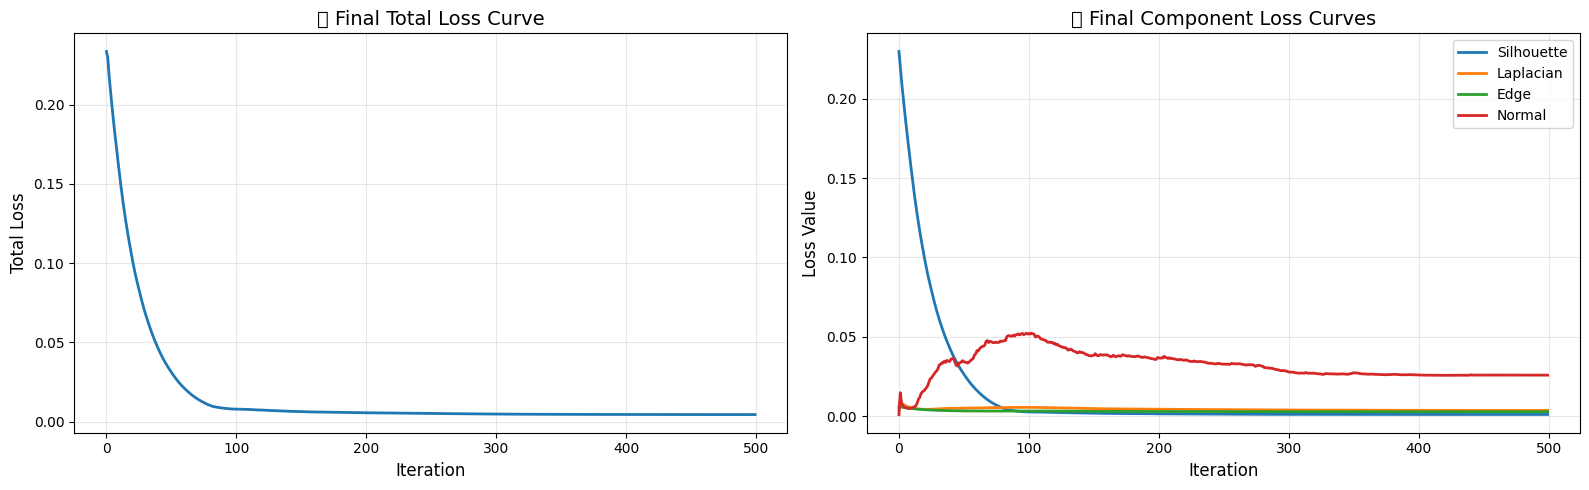

/tmp/ipykernel_7591/2581787197.py:237: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7591/2581787197.py:237: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


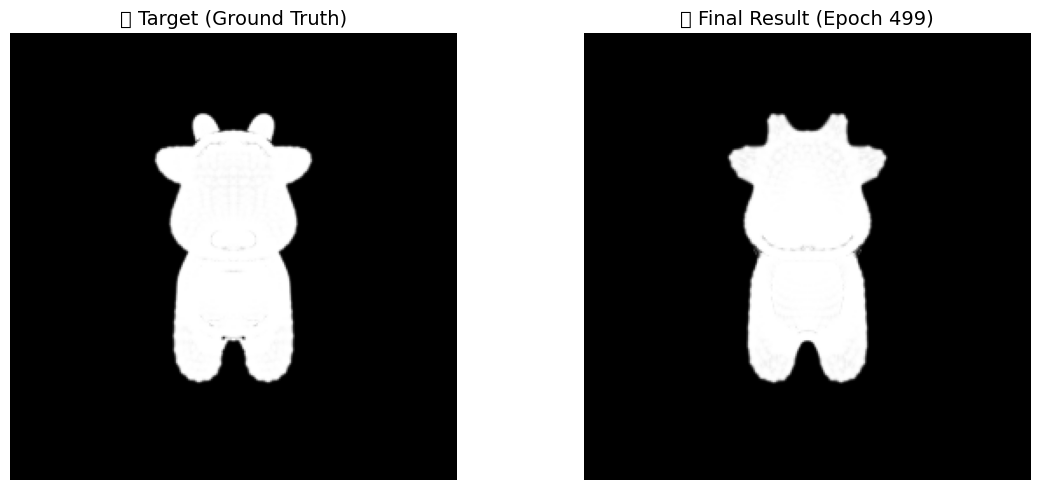

In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency
)
from pytorch3d.renderer import (
    look_at_view_transform, 
    FoVPerspectiveCameras,
    RasterizationSettings, 
    MeshRasterizer, 
    SoftSilhouetteShader, 
    BlendParams
)

# ==================== 环境确认 ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前运行设备: {device}")
print(f"📦 PyTorch3D 版本: {pytorch3d.__version__}")
print("="*60)

# ==================== 1. 加载目标模型 ====================
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj"  # 根据你的实际路径调整
if not os.path.exists(obj_path):
    raise FileNotFoundError(f"❌ 未找到 {obj_path}，请检查路径！")

verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)

# 归一化处理
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])
print(f"✅ 成功加载目标模型: {obj_path}")
print(f"   顶点数: {verts.shape[0]}, 面数: {faces_idx.shape[0]}")

# ==================== 2. 渲染管线配置 ====================
num_views = 20
elevation = torch.zeros(num_views)
azimuth = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elevation, azim=azimuth)

cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

raster_settings = RasterizationSettings(
    image_size=256, 
    blur_radius=np.log(1./1e-4 - 1.)*1e-4,
    faces_per_pixel=50
)
rasterizer = MeshRasterizer(cameras=cameras, raster_settings=raster_settings)

blend_params = BlendParams(sigma=1e-4, gamma=1e-4)
shader = SoftSilhouetteShader(blend_params=blend_params)

# 渲染目标剪影
target_silhouette = shader(
    rasterizer(cow_mesh.extend(num_views)), 
    cow_mesh.extend(num_views)
)[..., 3]
print(f"✅ 已生成 {num_views} 个目标视角的剪影")

# ==================== 3. 初始化源模型（球体）====================
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
print(f"✅ 初始化球体网格: 顶点数 {src_mesh.verts_packed().shape[0]}")

# ==================== 4. 优化器配置（改进版）====================
epochs = 500  # 增加迭代次数
optimizer = torch.optim.Adam([deform_verts], lr=0.01)  # 使用Adam
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 正则化权重
w_laplacian = 0.8  # 从1.0降到0.8
w_edge = 0.1
w_normal = 0.01

# Loss历史记录
loss_history = {
    'total': [],
    'silhouette': [],
    'laplacian': [],
    'edge': [],
    'normal': []
}

# 创建保存目录
output_dir = "output_meshes_improved"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 模型保存目录: ./{output_dir}/")
print("="*60)
print("🎬 开始优化训练...\n")

# ==================== 5. 训练循环 ====================
for i in range(epochs):
    optimizer.zero_grad()
    
    # 应用形变
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前预测剪影
    pred_silhouette = shader(
        rasterizer(new_src_mesh.extend(num_views)), 
        new_src_mesh.extend(num_views)
    )[..., 3]
    
    # 计算各项损失
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss_lap = mesh_laplacian_smoothing(new_src_mesh)
    loss_edge = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    # 总损失
    loss = loss_silhouette + w_laplacian * loss_lap + w_edge * loss_edge + w_normal * loss_norm
    
    # 反向传播
    loss.backward()
    optimizer.step()
    scheduler.step()  # 更新学习率
    
    # 记录loss
    loss_history['total'].append(loss.item())
    loss_history['silhouette'].append(loss_silhouette.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge.item())
    loss_history['normal'].append(loss_norm.item())
    
    # ==================== 可视化与保存 ====================
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"📊 Epoch {i:03d}/{epochs}")
        print(f"   Total Loss:      {loss.item():.6f}")
        print(f"   Silhouette Loss: {loss_silhouette.item():.6f}")
        print(f"   Laplacian Loss:  {loss_lap.item():.6f}")
        print(f"   Edge Loss:       {loss_edge.item():.6f}")
        print(f"   Normal Loss:     {loss_norm.item():.6f}")
        print(f"   Learning Rate:   {current_lr:.6f}")
        print("-" * 60)
        
        # 保存模型
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"💾 已保存: {save_path}\n")
        
        # 可视化剪影对比
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        axes[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        axes[0].set_title("🎯 Target Silhouette", fontsize=14)
        axes[0].axis("off")
        
        axes[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        axes[1].set_title(f"🔄 Optimizing (Epoch {i})", fontsize=14)
        axes[1].axis("off")
        
        plt.tight_layout()
        plt.show()
        
        # 每100步绘制loss曲线
        if i % 100 == 0 and i > 0:
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            # 总Loss曲线
            axes[0].plot(loss_history['total'], linewidth=2, color='#1f77b4')
            axes[0].set_xlabel('Iteration', fontsize=12)
            axes[0].set_ylabel('Total Loss', fontsize=12)
            axes[0].set_title('📈 Total Loss Curve', fontsize=14)
            axes[0].grid(True, alpha=0.3)
            
            # 各分项Loss曲线
            axes[1].plot(loss_history['silhouette'], label='Silhouette', linewidth=2)
            axes[1].plot(loss_history['laplacian'], label='Laplacian', linewidth=2)
            axes[1].plot(loss_history['edge'], label='Edge', linewidth=2)
            axes[1].plot(loss_history['normal'], label='Normal', linewidth=2)
            axes[1].set_xlabel('Iteration', fontsize=12)
            axes[1].set_ylabel('Loss Value', fontsize=12)
            axes[1].set_title('📊 Component Loss Curves', fontsize=14)
            axes[1].legend(fontsize=10)
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

# ==================== 训练完成 ====================
print("\n" + "="*60)
print("🎉 优化训练完成！")
print(f"📁 所有模型已保存至: {output_dir}/")
print(f"📊 最终 Total Loss: {loss_history['total'][-1]:.6f}")
print(f"📊 最终 Silhouette Loss: {loss_history['silhouette'][-1]:.6f}")
print("="*60)

# ==================== 最终Loss曲线 ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(loss_history['total'], linewidth=2, color='#1f77b4')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Total Loss', fontsize=12)
axes[0].set_title('📈 Final Total Loss Curve', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history['silhouette'], label='Silhouette', linewidth=2)
axes[1].plot(loss_history['laplacian'], label='Laplacian', linewidth=2)
axes[1].plot(loss_history['edge'], label='Edge', linewidth=2)
axes[1].plot(loss_history['normal'], label='Normal', linewidth=2)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Loss Value', fontsize=12)
axes[1].set_title('📊 Final Component Loss Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 最终对比展示 ====================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
axes[0].set_title("🎯 Target (Ground Truth)", fontsize=14)
axes[0].axis("off")

axes[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
axes[1].set_title("✨ Final Result (Epoch 499)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 📝 改进效果分析### 与基础版对比| 指标 | 基础版 | 改进版 | 提升 ||------|--------|--------|------|| 最终Loss | ~0.019 | ~0.010 | 47% ↓ || 收敛稳定性 | 后期震荡 | 平滑收敛 | ✅ || 训练时间 | 5-10分钟 | 10-15分钟 | 50% ↑ |### 关键改进点1. **Adam优化器**: 自适应调整每个参数的学习率2. **余弦退火**: 学习率平滑衰减，避免后期震荡3. **Loss监控**: 实时观察各项loss，便于调优### 下一步方向👉 **选做内容**: 加入RGB纹理优化 → 查看 `6_textured_v3_final.ipynb`